# Beginner EDA Practice Exercises

## Data Problems and Solutions

This notebook contains simple practice exercises for:

1. Initial Data Inspection
2. Missing Values
3. Duplicate Rows
4. Wrong Data Types
5. Invalid Values
6. Inconsistent Categories
7. Outliers
8. Class Imbalance

> Skewed Data is not included in this notebook.

For every task:

1. Read the instructions.
2. Complete the `TODO` lines.
3. Run the cell.
4. Check the result.

## Learning Goal

By the end of this notebook, students should be able to detect and treat common data-quality problems using basic Pandas functions.

# 1. Import Libraries

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


# 2. Create the Practice Dataset

The dataset below contains intentional problems.

Do not change `raw_df`. Create a copy for every task.

In [18]:
data = {
    "customer_id": [201, 202, 203, 204, 205, 205, 206, 207, 208, 209],
    "age": [22, 35, "unknown", 44, -5, -5, 39, 28, 135, 51],
    "city": [
        "Riyadh",
        "Jeddah",
        " riyadh ",
        "RIYADH",
        "Dammam",
        "Dammam",
        None,
        "JED",
        "Tabuk",
        "jeddah "
    ],
    "monthly_spend": [180, 320, 210, np.nan, 400, 400, 260, 195, 4200, 305],
    "satisfaction": [4, 5, 3, 4, 8, 8, np.nan, 2, 5, 4],
    "churn": ["No", "No", "Yes", "No", "No", "No", "No", "Yes", "No", "No"]
}

df = pd.DataFrame(data)

raw_df = df.copy()

display(raw_df)

,customer_id,age,city,monthly_spend,satisfaction,churn
0,201,22,Riyadh,180.0,4.0,No
1,202,35,Jeddah,320.0,5.0,No
2,203,unknown,riyadh,210.0,3.0,Yes
3,204,44,RIYADH,NaN,4.0,No
4,205,-5,Dammam,400.0,8.0,No
5,205,-5,Dammam,400.0,8.0,No
6,206,39,NaN,260.0,NaN,No
7,207,28,JED,195.0,2.0,Yes
8,208,135,Tabuk,4200.0,5.0,No
9,209,51,jeddah,305.0,4.0,No


# Task 1: Initial Data Inspection

Complete the following:

1. Display the first five rows.
2. Print the dataset shape.
3. Display the column names.
4. Display the data types.
5. Count the missing values.

In [19]:
task_1 = raw_df.copy()

# TODO 1: Display the first five rows.
display("first five rows", task_1.head(5))

# TODO 2: Print the shape.
print("\nShape:", task_1.shape)

# TODO 3: Display the column names.
print("\ncolumn names:", task_1.columns)

# TODO 4: Display the data types.
print("\ndata types:\n", task_1.dtypes)

# TODO 5: Count missing values.
print("\nmissing values:\n", task_1.isna().sum())

'first five rows'

,customer_id,age,city,monthly_spend,satisfaction,churn
0,201,22,Riyadh,180.0,4.0,No
1,202,35,Jeddah,320.0,5.0,No
2,203,unknown,riyadh,210.0,3.0,Yes
3,204,44,RIYADH,NaN,4.0,No
4,205,-5,Dammam,400.0,8.0,No



Shape: (10, 6)

column names: Index(['customer_id', 'age', 'city', 'monthly_spend', 'satisfaction', 'churn'], dtype='str')

data types:
 customer_id        int64
age               object
city                 str
monthly_spend    float64
satisfaction     float64
churn                str
dtype: object

missing values:
 customer_id      0
age              0
city             1
monthly_spend    1
satisfaction     1
churn            0
dtype: int64


## Check Your Understanding

Write your answers as comments:

- How many rows are there?
- Which column has the wrong data type?
- Which columns contain missing values?

In [20]:
# Number of rows: there are 10 rows

# Column with wrong data type: the age column. it's stored as 'object', but it should be stored as an int

# Columns with missing values: 3-columns ("city", "monthly_spend", "satisfaction")

# Task 2: Missing Values

Use a copy of `raw_df`.

Complete the following:

1. Count missing values.
2. Fill missing `monthly_spend` with the median.
3. Fill missing `city` with `"Unknown"`.
4. Fill missing `satisfaction` with the median.
5. Count missing values again.

In [21]:
task_2 = raw_df.copy()

# TODO 1: Count missing values.
print("missing values:\n", task_2.isna().sum(), sep="")

# TODO 2: Fill missing monthly_spend with the median.
#print(task_2["monthly_spend"])
spend_median = task_2["monthly_spend"].median()
task_2["monthly_spend"] = task_2["monthly_spend"].fillna(spend_median)
#print(task_2["monthly_spend"])

# TODO 3: Fill missing city with "Unknown".
#print(task_2["city"])
task_2["city"] = task_2["city"].fillna("Unknown")
#print(task_2["city"])

# TODO 4: Fill missing satisfaction with the median.
#print(task_2["satisfaction"])
satisfaction_median = task_2["satisfaction"].median()
task_2["satisfaction"] = task_2["satisfaction"].fillna(satisfaction_median)
#print(task_2["satisfaction"])

# TODO 5: Count missing values again.
print("missing values (after fixes):\n", task_2.isna().sum(), sep="")

missing values:
customer_id      0
age              0
city             1
monthly_spend    1
satisfaction     1
churn            0
dtype: int64
missing values (after fixes):
customer_id      0
age              0
city             0
monthly_spend    0
satisfaction     0
churn            0
dtype: int64


# Task 3: Duplicate Rows

Complete the following:

1. Count exact duplicate rows.
2. Display all copies of duplicated rows.
3. Remove exact duplicates.
4. Reset the index.
5. Print the shape before and after cleaning.

In [22]:
task_3 = raw_df.copy()

# TODO 1: Count duplicate rows.
print("count of duplicated rows:", task_3.duplicated().sum())

# TODO 2: Display duplicated rows.
print("\nduplicated rows:\n", task_3.duplicated(), sep="")

# Save the original shape before cleaning.
shape_before = task_3.shape

# TODO 3: Remove exact duplicates.
task_3 = task_3.drop_duplicates()

# TODO 4: Reset the index.
task_3 = task_3.reset_index(drop=True)

# TODO 5: Print the shape before and after.
print("\nshape before:", shape_before)
print("shape after:", task_3.shape)

count of duplicated rows: 1

duplicated rows:
0    False
1    False
2    False
3    False
4    False
5     True
6    False
7    False
8    False
9    False
dtype: bool

shape before: (10, 6)
shape after: (9, 6)


# Task 4: Wrong Data Type

The `age` column contains the word `"unknown"`.

Complete the following:

1. Display the current `age` data type.
2. Convert `age` to numeric using `errors="coerce"`.
3. Display the new data type.
4. Count missing age values after conversion.

In [23]:
task_4 = raw_df.copy()

# TODO 1: Display the current age data type.
print("current 'age' column type:\n", task_4["age"].dtype, sep="")

# TODO 2: Convert age to numeric.
task_4["age"] = pd.to_numeric(task_4["age"], errors="coerce")

# TODO 3: Display the new age data type.
print("\ncurrent 'age' column type again:\n", task_4["age"].dtypes, sep="")

# TODO 4: Count missing age values.
print("\nmissing values:", task_4["age"].isna().sum())

current 'age' column type:
object

current 'age' column type again:
float64

missing values: 1


# Task 5: Invalid Values

Use these rules:

- Valid age: 0 to 100
- Valid satisfaction: 1 to 5

Complete the following:

1. Convert `age` to numeric.
2. Display invalid age rows.
3. Display invalid satisfaction rows.
4. Replace invalid values with `NaN`.
5. Fill missing age and satisfaction with their medians.
6. Verify the final ranges.

In [24]:
task_5 = raw_df.copy()

# TODO 1: Convert age to numeric.
task_5["age"] = pd.to_numeric(task_5["age"], errors="coerce")

# TODO 2: Display invalid ages.
invalid_age = (task_5["age"] < 0) | (task_5["age"] > 100)
print("invalid age rows:")
print(invalid_age)

# TODO 3: Display invalid satisfaction values.
invalid_satisfaction = (task_5["satisfaction"] < 1) | (task_5["satisfaction"] > 5)
print("\ninvalid satisfaction rows:")
print(invalid_satisfaction)

# TODO 4A: Replace invalid ages with NaN.
task_5.loc[invalid_age, "age"] = np.nan

# TODO 4B: Replace invalid satisfaction values with NaN.
task_5.loc[invalid_satisfaction, "satisfaction"] = np.nan

# TODO 5A: Fill missing ages with the median.
age_median = task_5["age"].median()
task_5["age"] = task_5["age"].fillna(age_median)

# TODO 5B: Fill missing satisfaction with the median.
satisfaction_median = task_5["satisfaction"].median()
task_5["satisfaction"] = task_5["satisfaction"].fillna(satisfaction_median)

# TODO 6: Print the final age and satisfaction ranges.
print(f"\nAge range : {task_5['age'].min()} to {task_5['age'].max()}")
print(f"Satisfaction range: {task_5['satisfaction'].min()} to {task_5['satisfaction'].max()}")

invalid age rows:
0    False
1    False
2    False
3    False
4     True
5     True
6    False
7    False
8     True
9    False
Name: age, dtype: bool

invalid satisfaction rows:
0    False
1    False
2    False
3    False
4     True
5     True
6    False
7    False
8    False
9    False
Name: satisfaction, dtype: bool

Age range : 22.0 to 51.0
Satisfaction range: 2.0 to 5.0


# Task 6: Inconsistent Categories

Clean the `city` column in this order:

1. Fill missing values with `"Unknown"`.
2. Convert values to strings.
3. Remove extra spaces.
4. Convert text to lowercase.
5. Replace `"jed"` with `"jeddah"`.
6. Convert values to title case.
7. Display the final category counts.

In [25]:
task_6 = raw_df.copy()

# TODO: Clean the city column using method chaining.
task_6["city"] = (
      task_6["city"]
      .fillna("Unknown")
      .astype(str)
      .str.strip()
      .str.lower()
      .replace({"jed": "jeddah"})
      .str.title()
)

# TODO: Display the final value counts.
print(task_6["city"].value_counts())

city
Riyadh     3
Jeddah     3
Dammam     2
Unknown    1
Tabuk      1
Name: count, dtype: int64


# Task 7: Outliers

Use the IQR method on `monthly_spend`.

Complete the following:

1. Calculate Q1.
2. Calculate Q3.
3. Calculate IQR.
4. Calculate lower and upper limits.
5. Display possible outlier rows.
6. Create a new column called `monthly_spend_capped`.
7. Compare the original and capped values.

In [26]:
task_7 = raw_df.copy()

# TODO 1: Calculate Q1.
q1 = task_7["monthly_spend"].quantile(0.25)

# TODO 2: Calculate Q3.
q3 = task_7["monthly_spend"].quantile(0.75)

# TODO 3: Calculate IQR.
iqr = q3 - q1

# TODO 4: Calculate lower and upper limits.
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

# TODO 5: Display possible outliers.
is_outlier = (task_7["monthly_spend"] < lower) | (task_7["monthly_spend"] > upper)
print("possible outliers:\n", task_7[is_outlier], sep="")

# TODO 6: Create monthly_spend_capped using clip().
task_7["monthly_spend_capped"] = task_7["monthly_spend"].clip(lower=lower, upper=upper)

# TODO 7: Compare original and capped values.
display(task_7[["customer_id", "monthly_spend_capped", "monthly_spend"]])

possible outliers:
   customer_id  age   city  monthly_spend  satisfaction churn
8          208  135  Tabuk         4200.0           5.0    No


,customer_id,monthly_spend_capped,monthly_spend
0,201,180.0,180.0
1,202,320.0,320.0
2,203,210.0,210.0
3,204,NaN,NaN
4,205,400.0,400.0
5,205,400.0,400.0
6,206,260.0,260.0
7,207,195.0,195.0
8,208,685.0,4200.0
9,209,305.0,305.0


## Optional Visualization

Create a box plot for `monthly_spend`.

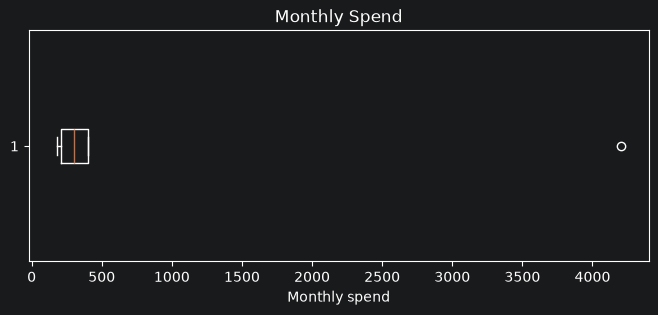

In [27]:
task_7_plot = raw_df.copy()

# TODO: Create a horizontal box plot for monthly_spend.
figure, axis = plt.subplots(figsize=(8, 3))
axis.boxplot(task_7_plot["monthly_spend"].dropna(), orientation="horizontal")
axis.set_title("Monthly Spend")
axis.set_xlabel("Monthly spend")
plt.show()

# Task 8: Class Imbalance

Use the `churn` column.

Complete the following:

1. Count each class.
2. Calculate the class percentages.
3. Display both in one DataFrame.
4. Draw a bar chart.
5. Check whether the percentages sum to 100.
6. Write whether the target is balanced or imbalanced.

,count,percentage
churn,,
No,8,80.0
Yes,2,20.0


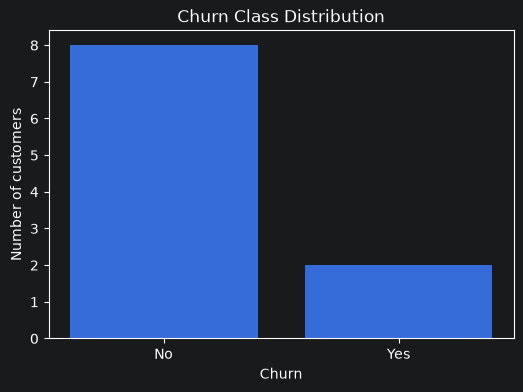

Sum of percentages: 100.0


In [28]:
task_8 = raw_df.copy()

# TODO 1: Count churn classes.
churn_counts = task_8["churn"].value_counts()

# TODO 2: Calculate percentages.
churn_percentages = task_8["churn"].value_counts(normalize=True) * 100

# TODO 3: Create a summary DataFrame.
churn_summary = pd.DataFrame({
    "count": churn_counts,
    "percentage": churn_percentages,
})
display(churn_summary)

# TODO 4: Draw a bar chart.
figure, axis = plt.subplots(figsize=(6, 4))
axis.bar(churn_counts.index, churn_counts.values)
axis.set_title("Churn Class Distribution")
axis.set_xlabel("Churn")
axis.set_ylabel("Number of customers")
plt.show()

# TODO 5: Check that percentages sum to 100.
print("Sum of percentages:", churn_percentages.sum())

# Conclusion: target is imbalanced. 80% of the records fall under one category, while the other 20% falls under another.

# Final Challenge: Clean the Complete Dataset

Create a DataFrame called `clean_df`.

Complete these steps:

1. Remove exact duplicate rows.
2. Convert `age` to numeric.
3. Replace invalid ages with `NaN`.
4. Replace invalid satisfaction values with `NaN`.
5. Fill missing age with the median.
6. Fill missing monthly spending with the median.
7. Fill missing satisfaction with the median.
8. Standardize city values.
9. Create a capped spending column using IQR.
10. Verify duplicates, missing values, valid ranges, and final categories.

In [29]:
clean_df = raw_df.copy()

# TODO 1: Remove exact duplicates.
clean_df = clean_df.drop_duplicates().reset_index(drop=True)

# TODO 2: Convert age to numeric.
clean_df["age"] = pd.to_numeric(clean_df["age"], errors="coerce")

# TODO 3: Replace invalid ages with NaN.
clean_df.loc[(clean_df["age"] < 0) | (clean_df["age"] > 100), "age"] = np.nan

# TODO 4: Replace invalid satisfaction with NaN.
clean_df.loc[(clean_df["satisfaction"] < 1) | (clean_df["satisfaction"] > 5), "satisfaction"] = np.nan

# TODO 5: Fill missing age.
clean_df["age"] = clean_df["age"].fillna(clean_df["age"].median())

# TODO 6: Fill missing monthly_spend.
clean_df["monthly_spend"] = clean_df["monthly_spend"].fillna(clean_df["monthly_spend"].median())

# TODO 7: Fill missing satisfaction.
clean_df["satisfaction"] = clean_df["satisfaction"].fillna(clean_df["satisfaction"].median())

# TODO 8: Standardize city values.
clean_df["city"] = (
      clean_df["city"]
      .fillna("Unknown")
      .astype(str)
      .str.strip()
      .str.lower()
      .replace({"jed": "jeddah"})
      .str.title()
)

# TODO 9: Calculate IQR limits and create monthly_spend_capped.
q1 = clean_df["monthly_spend"].quantile(0.25)
q3 = clean_df["monthly_spend"].quantile(0.75)
iqr = q3 - q1
lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr
clean_df["monthly_spend_capped"] = clean_df["monthly_spend"].clip(lower=lower_limit, upper=upper_limit)

# TODO 10: Verify the final dataset.
print("duplicates:", clean_df.duplicated().sum())
print("\nmissing values:\n", clean_df.isna().sum(), sep="")
print(f"\nage range: {clean_df['age'].min()} to {clean_df['age'].max()}")
print(f"satisfaction range: {clean_df['satisfaction'].min()} to {clean_df['satisfaction'].max()}")
print("cities:", clean_df["city"].unique().tolist())

display(clean_df)

duplicates: 0

missing values:
customer_id             0
age                     0
city                    0
monthly_spend           0
satisfaction            0
churn                   0
monthly_spend_capped    0
dtype: int64

age range: 22.0 to 51.0
satisfaction range: 2.0 to 5.0
cities: ['Riyadh', 'Jeddah', 'Dammam', 'Unknown', 'Tabuk']


,customer_id,age,city,monthly_spend,satisfaction,churn,monthly_spend_capped
0,201,22.0,Riyadh,180.0,4.0,No,180.0
1,202,35.0,Jeddah,320.0,5.0,No,320.0
2,203,37.0,Riyadh,210.0,3.0,Yes,210.0
3,204,44.0,Riyadh,282.5,4.0,No,282.5
4,205,37.0,Dammam,400.0,4.0,No,400.0
5,206,39.0,Unknown,260.0,4.0,No,260.0
6,207,28.0,Jeddah,195.0,2.0,Yes,195.0
7,208,37.0,Tabuk,4200.0,5.0,No,485.0
8,209,51.0,Jeddah,305.0,4.0,No,305.0


# Reflection Questions

Answer in your own words:

1. What is the difference between a missing value and an invalid value?
2. Why should a duplicated ID not always be deleted?
3. Why is the median useful when outliers exist?
4. Why should an outlier be investigated before deletion?
5. Why can accuracy be misleading when the target classes are imbalanced?

In [30]:
# 1. What is the difference between a missing value and an invalid value?
# missing means the value isn't there at all (NaN). invalid means the value is there but impossible, like age 135 or satisfaction 8.

# 2. Why should a duplicated ID not always be deleted?
# because the rows might not be identical. the same customer could have two real records.

# 3. Why is the median useful when outliers exist?
# because outliers don't move the median, they only move the mean.

# 4. Why should an outlier be investigated before deletion?
# because it may be a typo, or an error with the system's data-handling that needs to be caught and fixed. it may also be a real value, like a customer who genuinely spends that much.

# 5. Why can accuracy be misleading when the target classes are imbalanced?
# because if 80% is "No", a model that always says "No" will get an 80% accuracy, which may imply at first that the model performs well, but it in fact does not.

# Submission Checklist

- [x] All code cells run without errors.
- [x] A separate copy was used for every task.
- [x] Missing values were treated.
- [x] Exact duplicates were removed.
- [x] Data types were corrected.
- [x] Invalid values were treated.
- [x] Categories were standardized.
- [x] Outliers were detected and capped.
- [x] Class balance was checked.
- [x] The final challenge was completed.